# Các Thông Số Cơ Bản Của Thống Kê Dữ Liệu Nhiều Biến

Notebook này sẽ trình bày cách tính toán các thông số thống kê cơ bản cho dữ liệu nhiều biến (multivariate data), bao gồm vector trung bình, ma trận hiệp phương sai và ma trận tương quan. Dữ liệu đầu vào là một ma trận $n \times p$, trong đó $n$ là số lượng quan sát (items) và $p$ là số lượng biến (variables).

## 1. Import Libraries

Để thực hiện các phép tính toán ma trận, chúng ta sẽ sử dụng thư viện `NumPy`.

In [30]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Generate Sample Multivariate Data

Chúng ta sẽ tạo ngẫu nhiên một ma trận dữ liệu $n \times p$ với $n \approx 50$ quan sát và $p = 3$ biến để mô phỏng các phép tính phía sau.

In [31]:
np.random.seed(42)  # For reproducibility
n = 50
p = 3
true_mean = np.array([10.0, 20.0, 30.0])
true_scale = np.array([2.0, 3.0, 4.0])
noise = np.random.randn(n, p)
data = true_mean + noise * true_scale

print(f"Generated random data matrix ({n} observations, {p} variables):")
print(data)

Generated random data matrix (50 observations, 3 variables):
[[10.99342831 19.5852071  32.59075415]
 [13.04605971 19.29753988 29.06345217]
 [13.15842563 22.30230419 28.12210246]
 [11.08512009 18.60974692 28.13708099]
 [10.48392454 14.26015927 23.10032867]
 [ 8.87542494 16.96150664 31.25698933]
 [ 8.18395185 15.7630889  35.86259508]
 [ 9.5484474  20.20258461 24.30100726]
 [ 8.91123455 20.33276777 25.39602569]
 [10.75139604 18.19808393 28.833225  ]
 [ 8.79658678 25.55683455 29.9460111 ]
 [ 7.88457814 22.46763474 25.1166254 ]
 [10.41772719 14.12098963 24.6872558 ]
 [10.39372247 22.21539974 30.68547312]
 [ 9.76870344 19.09668891 24.08591204]
 [ 8.56031158 18.61808369 34.2284889 ]
 [10.68723658 14.71087953 31.29633588]
 [ 9.22983544 17.969234   32.44670516]
 [12.06199904 22.79384036 26.64312991]
 [ 9.38157525 20.99379029 33.90218051]
 [ 9.04165152 19.44302307 25.5746601 ]
 [ 7.60758675 22.43757747 35.42496011]
 [ 9.85597976 23.01059869 31.4465441 ]
 [ 8.70976049 21.08418682 36.15214627]
 [ 

## 3. Calculate Mean Vector

Vector trung bình $\bar{\mathbf{x}} = [\bar{x}_1, \bar{x}_2, \ldots, \bar{x}_p]^T$ được tính bằng cách lấy trung bình của từng biến: $\bar{x}_j = \frac{1}{n} \sum_{i=1}^{n} x_{ij}$.

In [32]:
mean_vector = np.zeros(p, dtype=float)
for j in range(p):
    column_sum = 0.0
    for i in range(n):
        column_sum += data[i, j]
    mean_vector[j] = column_sum / n

print("Mean Vector:")
print(mean_vector)

Mean Vector:
[ 9.90710837 19.66641787 29.64263703]


## 4. Calculate Variance Vector

Phương sai mẫu của từng biến phản ánh mức độ phân tán riêng lẻ: $s_j^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_{ij} - \bar{x}_j)^2$. Ta sẽ tự triển khai công thức này thông qua các vòng lặp.

In [33]:
variance_vector = np.zeros(p, dtype=float)
for j in range(p):
    accum = 0.0
    for i in range(n):
        diff = data[i, j] - mean_vector[j]
        accum += diff * diff
    variance_vector[j] = accum / (n - 1)

print("Variance Vector (sample variance for each variable):")
print(variance_vector)

Variance Vector (sample variance for each variable):
[ 2.25783701  9.20218867 17.77812722]


## 5. Calculate Covariance Matrix

Ma trận hiệp phương sai $S$ đo lường mức độ biến thiên cùng nhau của các biến và được tính bằng: $S_{jk} = \frac{1}{n-1} \sum_{i=1}^{n} (x_{ij} - \bar{x}_j)(x_{ik} - \bar{x}_k)$.

In [34]:
cov_matrix = np.zeros((p, p), dtype=float)
for j in range(p):
    for k in range(p):
        accum = 0.0
        for i in range(n):
            diff_j = data[i, j] - mean_vector[j]
            diff_k = data[i, k] - mean_vector[k]
            accum += diff_j * diff_k
        cov_matrix[j, k] = accum / (n - 1)

print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[ 2.25783701 -0.71660952 -1.45062959]
 [-0.71660952  9.20218867 -0.53708039]
 [-1.45062959 -0.53708039 17.77812722]]


## 6. Calculate Correlation Matrix

Ma trận hệ số tương quan $R$ chuẩn hóa hiệp phương sai về khoảng $[-1, 1]$: $R_{jk} = \frac{S_{jk}}{\sqrt{S_{jj} S_{kk}}}$. Ta sẽ tính toán thủ công dựa trên ma trận hiệp phương sai và vector phương sai đã có.

In [35]:
corr_matrix = np.zeros((p, p), dtype=float)
for j in range(p):
    for k in range(p):
        denom = (variance_vector[j] * variance_vector[k]) ** 0.5
        if denom == 0:
            corr_matrix[j, k] = 0.0
        else:
            corr_matrix[j, k] = cov_matrix[j, k] / denom

print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
[[ 1.         -0.15721382 -0.22896401]
 [-0.15721382  1.         -0.04199047]
 [-0.22896401 -0.04199047  1.        ]]


## 7. Visualize Summary Statistics

Biểu diễn trực quan giúp nhận biết nhanh các mẫu hình giữa các biến. Ở đây ta minh họa:
- Biểu đồ cột cho vector trung bình và phương sai.
- Heatmap cho ma trận hiệp phương sai và hệ số tương quan.

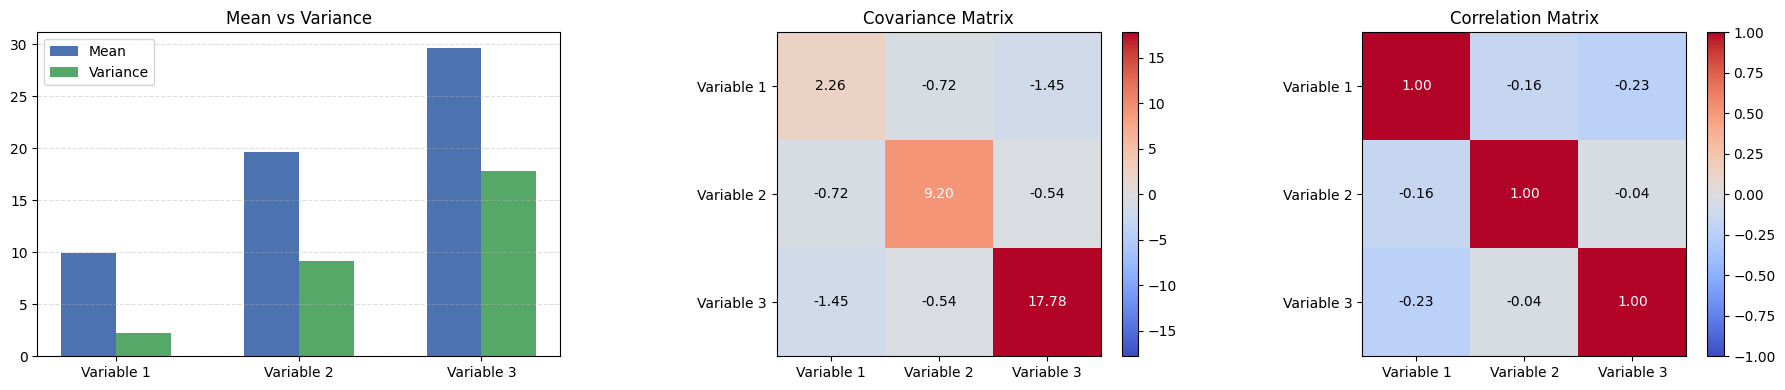

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
var_labels = [f"Variable {idx+1}" for idx in range(p)]
positions = np.arange(p)

# Bar chart to compare mean vs variance magnitude per variable
axes[0].bar(positions - 0.15, mean_vector, width=0.3, label="Mean", color="#4C72B0")
axes[0].bar(positions + 0.15, variance_vector, width=0.3, label="Variance", color="#55A868")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(var_labels)
axes[0].set_title("Mean vs Variance")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

heatmap_targets = [
    (cov_matrix, "Covariance Matrix"),
    (corr_matrix, "Correlation Matrix")
]

for ax, (matrix, title) in zip(axes[1:], heatmap_targets):
    scale = np.max(np.abs(matrix)) or 1.0
    im = ax.imshow(matrix, cmap="coolwarm", vmin=-scale, vmax=scale)
    ax.set_xticks(positions)
    ax.set_yticks(positions)
    ax.set_xticklabels(var_labels)
    ax.set_yticklabels(var_labels)
    ax.set_title(title)
    for row in range(p):
        for col in range(p):
            value = matrix[row, col]
            text_color = "white" if abs(value) > scale * 0.5 else "black"
            ax.text(col, row, f"{value:.2f}", ha="center", va="center", color=text_color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 8. Hình Học Của Các Thông Số

- Vector trung bình là tâm hình học (centroid) của đám mây điểm.
- Ma trận hiệp phương sai mô tả hình dạng ellip bao trùm dữ liệu thông qua các trị riêng.
- Ma trận tương quan giữ nguyên hướng ellip nhưng thu nhỏ theo độ dài chuẩn hóa.

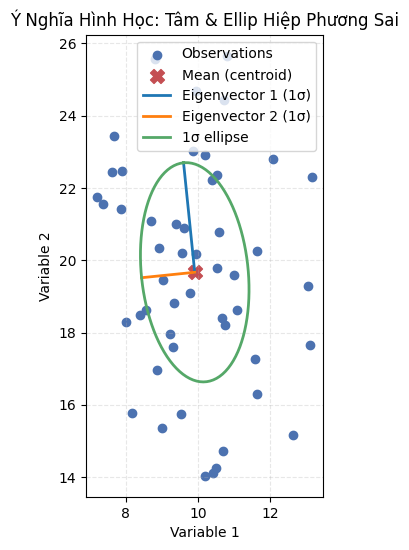

In [37]:
if p < 2:
    print("Cần ít nhất 2 biến để minh hoạ hình học trong mặt phẳng.")
else:
    mean_2d = mean_vector[:2]
    cov_2d = cov_matrix[:2, :2]
    data_2d = data[:, :2]

    def eigen_decomposition_2x2(matrix_2x2):
        a = matrix_2x2[0, 0]
        b = matrix_2x2[0, 1]
        c = matrix_2x2[1, 0]
        d = matrix_2x2[1, 1]
        trace = a + d
        determinant = a * d - b * c
        discriminant = trace * trace - 4.0 * determinant
        discriminant = discriminant if discriminant > 0 else 0.0
        sqrt_disc = discriminant ** 0.5
        lambda1 = 0.5 * (trace + sqrt_disc)
        lambda2 = 0.5 * (trace - sqrt_disc)

        def normalize(vec):
            norm = (vec[0] * vec[0] + vec[1] * vec[1]) ** 0.5
            if norm == 0:
                return np.array([1.0, 0.0], dtype=float)
            return vec / norm

        vec1 = np.array([b, lambda1 - a], dtype=float)
        if abs(vec1[0]) < 1e-10 and abs(vec1[1]) < 1e-10:
            vec1 = np.array([lambda1 - d, c], dtype=float)
        vec1 = normalize(vec1)
        vec2 = np.array([-vec1[1], vec1[0]], dtype=float)

        eigenvalues = np.array([lambda1, lambda2], dtype=float)
        eigenvectors = np.zeros((2, 2), dtype=float)
        for row in range(2):
            eigenvectors[row, 0] = vec1[row]
            eigenvectors[row, 1] = vec2[row]
        return eigenvalues, eigenvectors

    eigen_vals, eigen_vecs = eigen_decomposition_2x2(cov_2d)
    std_lengths = np.zeros(2, dtype=float)
    for idx in range(2):
        std_lengths[idx] = eigen_vals[idx] if eigen_vals[idx] > 0 else 0.0
        std_lengths[idx] = std_lengths[idx] ** 0.5

    angle_samples = np.linspace(0, 2 * np.pi, 200)
    ellipse_points = np.zeros((angle_samples.size, 2), dtype=float)
    for idx, angle in enumerate(angle_samples):
        unit_circle = np.array([np.cos(angle), np.sin(angle)], dtype=float)
        scaled = np.zeros(2, dtype=float)
        for j in range(2):
            scaled[j] = std_lengths[j] * unit_circle[j]
        transformed = np.zeros(2, dtype=float)
        for row in range(2):
            for col in range(2):
                transformed[row] += eigen_vecs[row, col] * scaled[col]
        ellipse_points[idx] = mean_2d + transformed

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(data_2d[:, 0], data_2d[:, 1], color="#4C72B0", label="Observations")
    ax.scatter(mean_2d[0], mean_2d[1], color="#C44E52", marker="X", s=100, label="Mean (centroid)")

    for idx in range(2):
        direction = np.zeros(2, dtype=float)
        for row in range(2):
            direction[row] = eigen_vecs[row, idx] * std_lengths[idx]
        ax.plot(
            [mean_2d[0], mean_2d[0] + direction[0]],
            [mean_2d[1], mean_2d[1] + direction[1]],
            linewidth=2,
            label=f"Eigenvector {idx+1} (1σ)"
        )

    ax.plot(ellipse_points[:, 0], ellipse_points[:, 1], color="#55A868", linewidth=2, label="1σ ellipse")
    ax.set_xlabel("Variable 1")
    ax.set_ylabel("Variable 2")
    ax.set_title("Ý Nghĩa Hình Học: Tâm & Ellip Hiệp Phương Sai")
    ax.legend(loc="best")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_aspect("equal", adjustable="box")
    plt.show()